In [15]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import numpy as np

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,RSI,RSI_Strategy,BB_SMA,BB_STD,Upper_Band,Lower_Band,BB_Strategy,Full_Strategy,Strategy,Asset_Returns,Strategy_Returns
32,47.793873,48.143600,46.883262,47.035030,5421000,53.026562,0.0,45.550680,1.542962,47.093642,44.007718,NaN,NaN,0,NaN,NaN
33,47.061409,48.381134,46.460934,48.143584,16482800,52.093150,0.0,45.639099,1.577697,47.216797,44.061402,-1.0,-1.0,0,-0.015325,0.000000
34,45.451378,46.823893,45.246820,46.665526,7676800,45.371224,0.0,45.662854,1.570754,47.233608,44.092101,0.0,0.0,0,-0.049012,0.000000
35,45.081856,45.504168,44.131653,45.240223,19148200,43.223271,0.0,45.701126,1.545340,47.246466,44.155786,0.0,0.0,0,-0.056744,0.000000
36,45.372177,45.952857,43.762112,45.715306,15295200,45.213176,0.0,45.707725,1.543549,47.251274,44.164175,0.0,0.0,0,-0.050670,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6789,599.750000,606.000000,598.330017,600.309998,86302300,48.499530,0.0,607.102493,4.948693,612.051186,602.153801,0.0,0.0,0,11.548680,41.164141
6790,607.760010,609.270020,591.330017,594.229980,93068200,54.052705,0.0,607.007993,4.915419,611.923411,602.092574,1.0,1.0,0,11.716275,41.164141
6791,607.770020,613.289978,605.419983,607.780029,64078900,51.316164,0.0,606.680493,4.611402,611.291895,602.069092,0.0,0.0,0,11.716484,41.164141
6792,607.690002,612.429993,605.030029,608.950012,59389500,52.891218,0.0,606.491495,4.480373,610.971867,602.011122,0.0,0.0,0,11.714810,41.164141


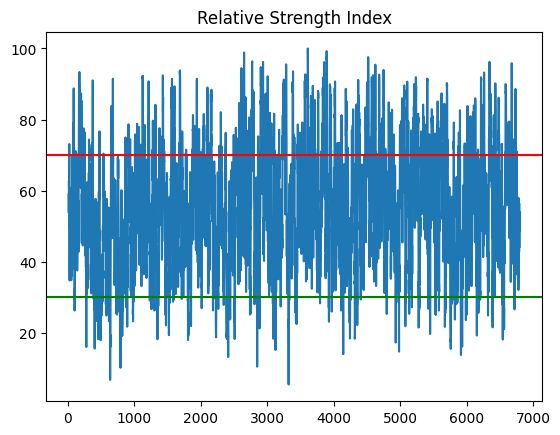

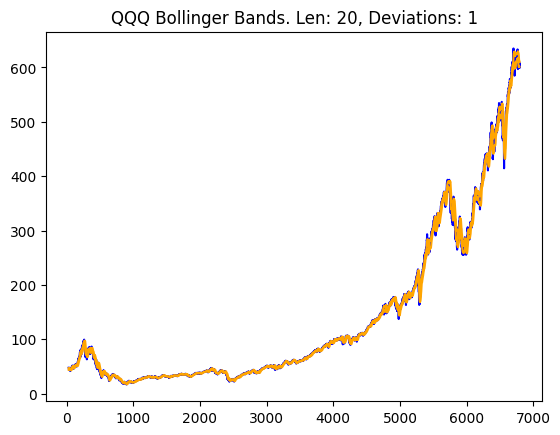

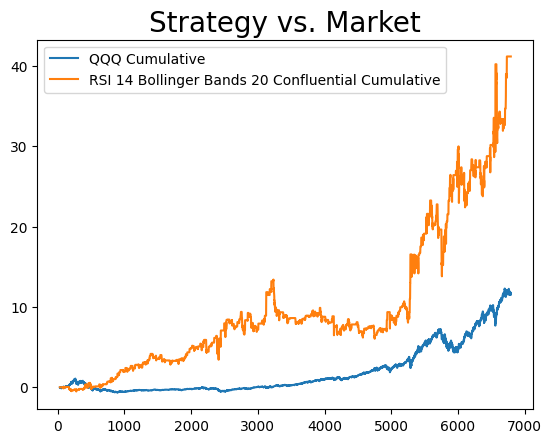

In [16]:
TICKER = 'QQQ'
INTERVAL='1d'

# set period based on interval
if INTERVAL == '1h':
    PERIOD = '730d'
else:
    PERIOD = 'max'

BB_LEN = 20
DEVS = 1
RSI_LENGTH = 14
RSI_OVERBOUGHT = 70
RSI_OVERSOLD = 30

# what subsetion of that data are you interested in
LOOKBACK = 10000

def get_data(ticker=TICKER, lookback=LOOKBACK, interval=INTERVAL):

    # get data at interval you want
    df = yf.download(ticker, interval=interval, period=PERIOD)
    df.columns = df.columns.get_level_values(0)

    # reset the index to make plots prettier
    df = df.reset_index(drop=True)

    # only return the subset of data you are interested in
    return df.iloc[-lookback:, :]

def add_RSI(df, length=RSI_LENGTH, overbought=RSI_OVERBOUGHT, oversold=RSI_OVERSOLD):

    price_change = df['Close'].diff()
    
    # separate gains/losses
    gain = price_change.where(price_change > 0, 0)
    loss = -price_change.where(price_change < 0, 0)

    # average gain vs loss
    avg_gain = gain.rolling(window=length).mean()
    avg_loss = loss.rolling(window=length).mean()

    # calculate rsi
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    df['RSI'] = rsi

    # plot the relative strength index
    plt.plot(df['RSI'])
    plt.axhline(overbought, color='red')
    plt.axhline(oversold, color='green')
    plt.title('Relative Strength Index')

    return df.dropna()

def add_RSI_strategy(df, overbought=RSI_OVERBOUGHT, oversold=RSI_OVERSOLD):

    df['RSI_Strategy'] = 0
    df['RSI_Strategy'] = np.where(df['RSI'] > overbought, -1, 
                     np.where(df['RSI'] < oversold, 1, 0))
    
    # shift back to make sure we have seen the signal
    df['RSI_Strategy'] = df['RSI_Strategy'].shift(1)
    return df

def add_BB(df, devs=DEVS, bb_len=BB_LEN):

    # can change to ema (use MACD video/code for reference)
    df['BB_SMA'] = df['Close'].rolling(bb_len).mean()

    # get the standard deviation of the close prices for the period
    df['BB_STD'] = df['Close'].rolling(bb_len).std()

    df['Upper_Band'] = df['BB_SMA'] + (devs * df['BB_STD'])
    df['Lower_Band'] = df['BB_SMA'] - (devs * df['BB_STD'])

    df = df.dropna()

    plt.figure()
    plt.plot(df['Close'], color='blue')
    plt.plot(df['Upper_Band'], color='orange')
    plt.plot(df['Lower_Band'], color='orange')

    plt.title(f'{TICKER} Bollinger Bands. Len: {BB_LEN}, Deviations: {DEVS}');

    return df

def add_BB_strategy(df):
    df['BB_Strategy'] = 0
    df['BB_Strategy'] = np.where(
        df['Close'] > df['Upper_Band'], -1, 
        np.where(df['Close'] < df['Lower_Band'], 1, 0)
        )
    
    df['BB_Strategy'] = df['BB_Strategy'].shift(1)
    
    return df

def add_full_strategy(df):

    df['Full_Strategy'] = df['RSI_Strategy'] + df['BB_Strategy']

    # adjust values for simplicity
    df['Strategy'] = np.where(df['Full_Strategy'] == 2, 3, 
                     np.where(df['Full_Strategy'] == -2, -3, 0))

    return df

def test_strategy(df):

    df['Asset_Returns'] = (1 + df['Close'].pct_change()).cumprod() - 1
    df['Strategy_Returns'] = (1 + df['Close'].pct_change() * df['Strategy']).cumprod() -1

    plt.figure()
    plt.plot(df['Asset_Returns'])
    plt.plot(df['Strategy_Returns'])
    plt.legend([f'{TICKER} Cumulative', f'RSI {RSI_LENGTH} Bollinger Bands {BB_LEN} Confluential Cumulative'])
    plt.title('Strategy vs. Market', size='20')

    return df

def main():
    df = get_data()
    df = add_RSI(df)
    df = add_RSI_strategy(df)
    df = add_BB(df)
    df = add_BB_strategy(df)
    df = add_full_strategy(df)
    df = test_strategy(df)

    return df

df = main()

df